# Flow compensation across a multi-echo gradient-echo train

A multi-echo gradient echo (MEGRE) excites a slice once, encodes one line of k-space, and then
reads that line out **several times** — the readout gradient sweeps back and forth across $k_x$,
producing an echo on each traverse, so one excitation yields images at several echo times. The
decay of signal magnitude across those echo times gives $T_2^*$; the growth of signal *phase*
across them gives the field map that susceptibility-weighted imaging and quantitative
susceptibility mapping are built on. [`01_build`](01_build.ipynb) builds the train and
[`02_simulate_and_reconstruct`](02_simulate_and_reconstruct.ipynb) images with it.

Because those applications read the phase, anything else that writes phase is a confound — and
motion is the main one. A spin moving at constant velocity $v$ along an axis accumulates, by the
echo,

$$\phi \;=\; 2\pi \int_{t_0}^{t_\text{echo}} G(t)\, x(t)\, \mathrm{d}t
        \;=\; 2\pi\left[\, M_0\, x_0 \;+\; M_1\, v \,\right],
\qquad
M_n \;=\; \int_{t_0}^{t_\text{echo}} G(t)\,(t - t_0)^n\, \mathrm{d}t$$

where $t_0$ is the RF effective centre — the instant transverse magnetisation is created and the
instant its phase starts from — and $x(t) = x_0 + v\,(t-t_0)$. **Flow compensation**, or
first-moment nulling, is the design of the gradients so that $M_1 = 0$, which removes the
velocity term and leaves only the position term the encoding wants.
[`gre_2d/03_flow_comp`](../gre_2d/03_flow_comp.ipynb) does this for a single-echo gradient echo.

A single-echo sequence has one echo, so $M_1 = 0$ is one condition. A four-echo train has four
echoes, and the gradients that produce echoes 2, 3 and 4 play *after* echo 1 — so a condition met
once does not survive on its own. In SeqCraft, `flow_comp=` on a train means **$M_1 = 0$ at every
acquired echo**, and this notebook measures that, shows what carries the condition from one echo
to the next, and shows what it costs in echo spacing.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pypulseq as pp

import seqcraft as sc

opts = pp.Opts(
    max_grad=40, grad_unit='mT/m',
    max_slew=150, slew_unit='T/m/s',
    B0=3.0,
    rf_dead_time=100e-6,
    rf_ringdown_time=30e-6,
    adc_dead_time=10e-6,
)

FOV_MM, MATRIX, THICKNESS_MM = 220.0, 64, 5.0
BANDWIDTH_HZ_PX, ECHOES = 500.0, 4
RF_SPOIL_DEG = 117.0

# Enough to show the pattern, not a converged steady state -- §8 says what that distinction is.
DUMMIES = 8

# Every measurement below uses a line well off the centre of k-space, so that `M0` on the
# phase-encode axis is the line's own non-zero `ky` rather than a value that happens to be zero.
LINE = MATRIX // 4

FULL = sc.FlowCompensation(axis=('x', 'y', 'z'))
SEQ_DIR = Path('seq')
SEQ_DIR.mkdir(exist_ok=True)


def megre(polarity, **kwargs):
    return sc.modules.GRE2DTR(opts=opts, fov_mm=FOV_MM, matrix=(MATRIX, MATRIX),
                              thickness_mm=THICKNESS_MM, bandwidth_hz_px=BANDWIDTH_HZ_PX,
                              echoes=ECHOES, polarity=polarity, **kwargs)


def echo_times(kernel):
    '''Absolute instant of every echo, measured from the start of the repetition.

    `time_to_echo()` is the first echo of the train and `ro.te_s` locates the rest of them
    inside the readout block, so the offsets carry over unchanged.
    '''
    first = kernel.time_to_echo()
    return tuple(first + (t - kernel.ro.te_s[0]) for t in kernel.ro.te_s)


print(f'{ECHOES} echoes, {MATRIX}x{MATRIX}, {BANDWIDTH_HZ_PX:.0f} Hz/px, line {LINE} of {MATRIX}\n')
for polarity in ('monopolar', 'bipolar'):
    kernel = megre(polarity)
    t0 = kernel.exc.time_to_center()
    echoes = ', '.join(f'{(t - t0) * 1e3:.3f}' for t in echo_times(kernel))
    print(f'{polarity:>10}   echo spacing {kernel.ro.echo_spacing_s * 1e6:7.1f} us'
          f'   TE {echoes} ms')

/opt/homebrew/Caskroom/miniforge/base/envs/seqcraft-dev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


4 echoes, 64x64, 500 Hz/px, line 16 of 64

 monopolar   echo spacing  2500.0 us   TE 3.114, 5.614, 8.114, 10.614 ms
   bipolar   echo spacing  2080.0 us   TE 3.126, 5.174, 7.286, 9.334 ms


---

## 1. Measuring a moment at every echo

The moment is a property of the waveform, so the way to read it is to integrate the events the
sequence actually plays. Two instants define each measurement and both need saying:

```text
integration interval   [t0, TE_n]   the gradient acts on the transverse signal over this
motion reference       t0           position and velocity are parameterised about this
```

The interval starts at the RF effective centre because that is when transverse magnetisation
exists — a slice-select lobe that plays *before* it dephases nothing. The reference is a choice,
and referencing to $t_0$ makes $M_1$ the velocity coefficient in the phase expression above.
Both are held fixed across the whole train here: **one origin, several endpoints**.

In [2]:
def moment(shot, order, axis, t0, end):
    '''M_n on one axis over [t0, end], referenced to t0.  Clips lobes straddling either instant.'''
    total = 0.0
    for start, event, _ in sc.flatten(shot):
        if getattr(event, 'channel', None) != axis:
            continue
        times, amps = sc.events.knots_of(event, start)
        if times.size < 2 or end <= times[0] or times[-1] <= t0:
            continue
        if times[0] < t0:
            cut = int(np.searchsorted(times, t0))
            edge = float(np.interp(t0, times, amps))
            times, amps = np.concatenate(([t0], times[cut:])), np.concatenate(([edge], amps[cut:]))
        if end < times[-1]:
            cut = int(np.searchsorted(times, end))
            edge = float(np.interp(end, times, amps))
            times, amps = np.concatenate((times[:cut], [end])), np.concatenate((amps[:cut], [edge]))
        # `knots_of` gives the event as a piecewise-linear waveform -- the corner points of the
        # ramps and flat tops -- and `pwl_moment` integrates that waveform exactly, analytically
        # rather than by sampling it. Subtracting `t0` from the knot times is what sets the
        # reference: order 0 is the plain area, order 1 is the integral against (t - t0).
        total += sc.events.pwl_moment(times - t0, amps, order)
    return float(total)


def table(kernel, axes=('x', 'y', 'z'), line=LINE):
    shot, t0 = kernel(line=line), kernel.exc.time_to_center()
    print(f'{"echo":>5}{"TE / ms":>10}' + ''.join(f'{f"M0 {a} / (1/m)":>16}{f"M1 {a} / (s/m)":>16}'
                                                  for a in axes))
    for n, te in enumerate(echo_times(kernel)):
        row = ''.join(f'{moment(shot, 0, a, t0, te):16.4f}{moment(shot, 1, a, t0, te):16.6e}'
                      for a in axes)
        print(f'{n:>5}{(te - t0) * 1e3:10.3f}{row}')
    return np.array([[moment(shot, 1, a, t0, te) for te in echo_times(kernel)] for a in axes])

---

## 2. The uncompensated train

Nothing here asks for flow compensation. The zeroth moments are the encoding — $k_x = 0$ at every
echo, which is what makes it an echo; $k_y$ the line's own value; $k_z = 0$ from the slice
rephaser — and the first moments are whatever the waveform happens to produce.

In [3]:
uncompensated = {}
for polarity in ('monopolar', 'bipolar'):
    print(f'{polarity}, no flow compensation')
    uncompensated[polarity] = table(megre(polarity))
    print()

monopolar, no flow compensation
 echo   TE / ms    M0 x / (1/m)    M1 x / (s/m)    M0 y / (1/m)    M1 y / (s/m)    M0 z / (1/m)    M1 z / (s/m)
    0     3.114         -0.0000    1.183505e-01        -72.7273   -1.316364e-01          0.0000   -4.259556e-01
    1     5.614          0.0000    1.234496e-01        -72.7273   -1.316364e-01          0.0000   -4.259556e-01
    2     8.114          0.0000    1.285487e-01        -72.7273   -1.316364e-01          0.0000   -4.259556e-01
    3    10.614          0.0000    1.336477e-01        -72.7273   -1.316364e-01          0.0000   -4.259556e-01

bipolar, no flow compensation
 echo   TE / ms    M0 x / (1/m)    M1 x / (s/m)    M0 y / (1/m)    M1 y / (s/m)    M0 z / (1/m)    M1 z / (s/m)
    0     3.126         -0.0000    1.194443e-01        -72.7273   -1.316364e-01          0.0000   -4.259556e-01
    1     5.174         -0.0000   -3.189596e-02        -72.7273   -1.316364e-01          0.0000   -4.259556e-01
    2     7.286         -0.0000    1.2889

$M_0$ behaves identically in both: $k_x$ returns to zero at every echo, $k_y$ holds the line, $k_z$
stays rephased. That is the readout doing its job, and it is the same at echo 4 as at echo 1.

$M_1$ does not hold still, and the two polarities are unalike:

```text
monopolar   M1x climbs monotonically, by an equal step each echo
bipolar     M1x alternates in sign, and does not return to where it started
```

$M_1$ on `y` and `z`, by contrast, is the *same number at every echo* — large, but constant. That
difference between the axes turns out to be the whole story, and §4 is about why.

---

## 3. Asking for flow compensation

`flow_comp=sc.FlowCompensation(axis=...)` adds $M_1 = 0$ as a condition alongside the
zeroth-moment condition each axis already has. On a train it means every acquired echo.

In [4]:
compensated = {}
for polarity in ('monopolar', 'bipolar'):
    print(f'{polarity}, flow_comp on x + y + z')
    compensated[polarity] = table(megre(polarity, flow_comp=FULL))
    print()

monopolar, flow_comp on x + y + z
 echo   TE / ms    M0 x / (1/m)    M1 x / (s/m)    M0 y / (1/m)    M1 y / (s/m)    M0 z / (1/m)    M1 z / (s/m)
    0     4.154          0.0000    3.330669e-16        -72.7273    1.110223e-16          0.0000    2.220446e-15
    1     6.734         -0.0000   -1.443290e-15        -72.7273    1.110223e-16          0.0000    2.220446e-15
    2     9.314          0.0000    6.661338e-16        -72.7273    1.110223e-16          0.0000    2.220446e-15
    3    11.894          0.0000    1.110223e-15        -72.7273    1.110223e-16          0.0000    2.220446e-15

bipolar, flow_comp on x + y + z


 echo   TE / ms    M0 x / (1/m)    M1 x / (s/m)    M0 y / (1/m)    M1 y / (s/m)    M0 z / (1/m)    M1 z / (s/m)
    0     4.166          0.0000    0.000000e+00        -72.7273    1.110223e-16          0.0000    2.220446e-15
    1     7.434         -0.0000   -1.554312e-15        -72.7273    1.110223e-16          0.0000    2.220446e-15
    2    10.766         -0.0000   -2.664535e-15        -72.7273    1.110223e-16          0.0000    2.220446e-15
    3    14.034          0.0000    8.881784e-16        -72.7273    1.110223e-16          0.0000    2.220446e-15



Every $M_1$ in both tables is at the floating-point round-off floor, $10^{-16}$ to $10^{-15}$,
on all three axes
and at all four echoes — while $k_y$ still holds the line at $-72.7273\ \mathrm{m^{-1}}$ and $k_x$
still returns to zero, so these are still the same echoes of the same acquisition.

The two halves of that result are bought very differently, and it is worth separating them.

---

## 4. Why later echoes cost nothing extra on `y` and `z`

Look at what actually plays between the first echo and the last.

In [5]:
for polarity in ('monopolar', 'bipolar'):
    kernel = megre(polarity, flow_comp=FULL)
    shot, echoes = kernel(line=LINE), echo_times(kernel)
    print(f'{polarity}: gradient events overlapping the train, ms from the start of the '
          f'repetition -- the train spans [{echoes[0] * 1e3:.3f}, {echoes[-1] * 1e3:.3f}]')
    for axis in ('x', 'y', 'z'):
        spans = []
        for start, event, _ in sc.flatten(shot):
            if getattr(event, 'channel', None) != axis:
                continue
            times, _ = sc.events.knots_of(event, start)
            if times[-1] > echoes[0] and times[0] < echoes[-1]:
                spans.append(f'[{times[0] * 1e3:.2f}, {times[-1] * 1e3:.2f}]')
        shown = ' '.join(spans[:4]) + (' ...' if len(spans) > 4 else '')
        print(f'   {axis}: {len(spans):>2} event(s)  {shown}')
    print()

monopolar: gradient events overlapping the train, ms from the start of the repetition -- the train spans [5.754, 13.494]
   x: 10 event(s)  [4.71, 6.77] [6.77, 6.81] [6.81, 7.29] [7.29, 9.35] ...
   y:  0 event(s)  
   z:  0 event(s)  



bipolar: gradient events overlapping the train, ms from the start of the repetition -- the train spans [5.766, 15.634]
   x: 10 event(s)  [4.71, 6.79] [6.79, 7.40] [7.40, 8.01] [8.01, 10.09] ...
   y:  0 event(s)  
   z:  0 event(s)  



**`y` and `z` are silent for the whole train.** The phase-encode winder and the slice rephaser
both finish before the first echo, and nothing on those axes plays again until after the last one.

That is the whole explanation, and it is worth stating as physics rather than as a coincidence: a
first moment taken about a **fixed** origin stops accruing the moment the gradient stops. $M_1$ is
$\int G(t)\,(t-t_0)\,\mathrm{d}t$, and where $G = 0$ the integrand is zero no matter how large the
lever arm $(t - t_0)$ has grown. Extending the interval from the first echo to the fourth adds
nothing.

So on an axis that is quiet across the train, **once the first echo is compensated, extending that
guarantee to the later echoes needs no additional inter-echo waveform and no additional time**.
Note what that does *not* say: compensating `y` and `z` at all is not free. It reshapes the winder
and pushes the first echo out, and §6 shows TE1 moving from 3.114 to 4.154 ms. What costs nothing
extra is carrying the condition from the first echo to the last.

`x` is not quiet. The readout is what makes the extra echoes, so the readout axis is where the
work is.

---

## 5. What the readout axis needs

Write $M_n^{(i)}$ for the moment at echo $i$, all about the same origin $t_0$. Splitting the
integral at the intermediate echo and expanding $(t - t_0) = (t - \text{TE}_i) + (\text{TE}_i -
t_0)$:

$$M_1^{(i+1)} \;=\; M_1^{(i)} \;+\; \underbrace{\int_{\text{TE}_i}^{\text{TE}_{i+1}}
   G(t)\,(t - \text{TE}_i)\,\mathrm{d}t}_{\textstyle \mu_i}
   \;+\; (\text{TE}_i - t_0)\underbrace{\int_{\text{TE}_i}^{\text{TE}_{i+1}} G(t)\,\mathrm{d}t}_{
   \textstyle a_i}$$

Every echo is a $k_x = 0$ crossing, so $a_i = M_0^{(i+1)} - M_0^{(i)} = 0$ and the lever-arm term
vanishes:

$$M_0^{(i+1)} = M_0^{(i)}, \qquad M_1^{(i+1)} = M_1^{(i)} + \mu_i$$

So the condition at echo $i+1$ is the condition at echo $i$ **plus $\mu_i$**, and $\mu_i$ is a
property of the inter-echo waveform alone — it references neither $t_0$ nor the echo time. Making
$M_1$ zero everywhere therefore needs two things: the winder nulls $M_1^{(0)}$, and every interval
has

$$\Delta M_0 = 0 \quad\text{and}\quad \Delta M_1 = 0 .$$

**The second condition is on the interval, not on any one event in it.** The interval contains a
part that is fixed and a part the design may choose:

```text
fixed        the post-echo tail of readout lobe i
             + the pre-echo head of readout lobe i+1

adjustable   whatever plays between the two lobes
```

and what the adjustable part has to do is cancel the **combined** contribution of the fixed parts.
"The fly-back's own first moment is zero" is a different, weaker statement, and a train built to it
would be compensated at the first echo only.

$\Delta M_0 = 0$ is not a new requirement: $\text{TE}_i$ and $\text{TE}_{i+1}$ are both
$k_x = 0$ crossings, so the post-echo tail of one lobe, whatever plays between, and the pre-echo
head of the next already carry zero net area between them. $\Delta M_1 = 0$ is the new one, and it
is what carries the velocity condition forward. Here is what the design put between the lobes:

In [6]:
def between_the_lobes(kernel, line=LINE):
    '''What the emitted block plays between each pair of readout lobes, and how long the gap is.

    Read off the block rather than asked of the module: a readout lobe is the event that carries
    an echo, which is the one property of it that does not depend on how the train was built.
    '''
    shot, echoes = kernel(line=line), echo_times(kernel)
    spans = []
    for start, event, _ in sc.flatten(shot):
        if getattr(event, 'channel', None) != 'x':
            continue
        times, _ = sc.events.knots_of(event, start)
        spans.append((float(times[0]), float(times[-1]), event))
    spans.sort()
    carries = [any(lo <= echo <= hi for echo in echoes) for lo, hi, _ in spans]
    groups = []
    for index in [i for i, is_lobe in enumerate(carries) if is_lobe][:-1]:
        following = carries.index(True, index + 1)
        groups.append(([event for _, _, event in spans[index + 1:following]],
                       spans[following][0] - spans[index][1]))
    return groups

print(f'{"polarity":>10}{"interval":>10}{"lobes between: area / (1/m)":>34}'
      f'{"gap / us":>11}')
for polarity in ('monopolar', 'bipolar'):
    # Two intervals is enough to show the alternation a bipolar train has and a monopolar one
    # does not; the rest of the train repeats them.
    for index, (events, gap) in enumerate(between_the_lobes(megre(polarity, flow_comp=FULL))[:2]):
        areas = ', '.join(f'{float(event.area):+10.2f}' for event in events)
        print(f'{polarity if index == 0 else "":>10}{index:>10}{areas:>34}{gap * 1e6:11.1f}')

  polarity  interval       lobes between: area / (1/m)   gap / us
 monopolar         0                 -2.51,    -293.24      520.0
                   1                 -2.51,    -293.24      520.0


   bipolar         0               -539.37,    +539.37     1220.0
                   1               +563.96,    -563.96     1220.0


The two polarities need structurally different waveforms, for a reason worth spelling out.

**Monopolar.** Every lobe is the same forward lobe, so $k_x$ has to be dragged back across the line
between echoes: the interval's fixed area is a whole lobe's worth and the transition has to cancel
it. That is the fly-back an uncompensated monopolar train already has — the design reshapes it into
two lobes so it can carry the first moment as well as the area. Because every lobe and every echo
position is identical, **one interval shape serves the whole train**.

**Bipolar.** The lobes alternate, so the second lobe undoes the first and the interval's fixed
area is already zero. The transition therefore carries **pure first moment**: a balanced pair,
equal and opposite, adding no area at all. But an uncompensated bipolar train has *no* gap between
its lobes — they abut, which is exactly what makes its echo spacing short — so this waveform has to
be created rather than reshaped. And the two interval directions are not the same: forward-to-
reverse and reverse-to-forward differ, because $k_x = 0$ is not the same sample index on a forward
and a reverse lobe. That is the same fact that makes a bipolar train's echo times alternate, which
[`01_build` §5](01_build.ipynb) is about, so the design solves **two** interval shapes and
alternates them.

---

## 6. What it costs

Nulling a first moment takes gradient area played at a lever arm, and that takes time. The
guarantee is paid for in echo spacing, and through it in echo time and repetition time.

In [7]:
print(f'{"polarity":>10}{"":>10}{"ESP / us":>11}{"gap / us":>11}'
      f'{"TE1 / ms":>10}{"last TE / ms":>14}{"min TR / ms":>13}')
for polarity in ('monopolar', 'bipolar'):
    for tag, extra in (('plain', {}), ('flow_comp', {'flow_comp': FULL})):
        kernel = megre(polarity, **extra)
        last = kernel.te_s + (kernel.ro.te_s[-1] - kernel.ro.te_s[0])
        gaps = between_the_lobes(kernel)
        gap = gaps[0][1] if gaps else 0.0
        print(f'{polarity if tag == "plain" else "":>10}{tag:>10}'
              f'{kernel.ro.echo_spacing_s * 1e6:11.1f}{gap * 1e6:11.1f}'
              f'{kernel.te_s * 1e3:10.3f}{last * 1e3:14.3f}{kernel.min_tr_s * 1e3:13.3f}')

  polarity             ESP / us   gap / us  TE1 / ms  last TE / ms  min TR / ms
 monopolar     plain     2500.0      440.0     3.114        10.614       14.190
           flow_comp     2580.0      520.0     4.154        11.894       16.060
   bipolar     plain     2080.0        0.0     3.126         9.334       12.950


           flow_comp     3300.0     1220.0     4.166        14.034       18.240


The monopolar train pays **3 %** on echo spacing: it already had a fly-back, and reshaping it into
a compensated pair is a small extension of a waveform that was there anyway. The bipolar train pays
**59 %**, because it had no inter-lobe waveform at all and the one it needs has to fit a balanced
pair between the lobes.

That reverses the usual reason to choose bipolar. Uncompensated, bipolar is the faster readout —
2080 µs against 2500 µs. Compensated at every echo, it is the slower one, 3300 µs against 2580 µs,
and the short echo spacing that motivated it is gone.

**Under this protocol and this gradient system, all-echo compensation reverses the echo-spacing
ordering of the two readouts.** That is a measurement of one 64×64, 500 Hz/px, four-echo protocol
on one amplifier, realised by the waveform family this readout implements — not a general law
about compensated multi-echo imaging. What is general is the structural reason behind it: a
monopolar train has an inter-echo region to reshape and a bipolar one has to make room for a new
waveform. How much that costs in any particular protocol is worth measuring rather than assuming.

`echo_spacing_s=None` asks for the shortest spacing that can carry the guarantee. A hard request is
honoured if it is feasible and refused with the minimum named if it is not:

In [8]:
readout = megre('bipolar', flow_comp=FULL).ro
print(f'shortest compensated bipolar spacing: {readout.min_echo_spacing_s * 1e6:.1f} us\n')
try:
    megre('bipolar', flow_comp=FULL, echo_spacing_s=2200e-6)
except sc.ConfigurationError as refused:
    print(refused)

shortest compensated bipolar spacing: 3300.0 us



echo_spacing_s = 2200.0 us is shorter than the minimum this train needs.
  echo_spacing_s        :  0.0022
  min_echo_spacing_s    :  0.0033
  polarity              :  bipolar
  bandwidth_hz_px       :  496.031746031746
  compensates_every_echo:  True
  fix
    pass echo_spacing_s >= 0.0033
    or echo_spacing_s=None for the shortest legal period
    a higher bandwidth_hz_px shortens the lobe, and with it the minimum
    this train nulls the first moment at every echo, which needs a waveform between the lobes and is most of this minimum
    a stronger max_slew lets that waveform carry the same moment in less time


The minimum is a property of the amplifier as well as the protocol, so the same request may be
feasible on one scanner and not on another. Which limit it depends on is worth separating, because
the two polarities answer differently. Hold the gradient ceiling fixed and vary only the slew
rate:

In [9]:
def minimum_esp(polarity, max_grad, max_slew):
    '''The shortest all-echo compensated spacing this protocol reaches on one gradient system.'''
    system = pp.Opts(max_grad=max_grad, grad_unit='mT/m', max_slew=max_slew, slew_unit='T/m/s',
                     B0=3.0, rf_dead_time=100e-6, rf_ringdown_time=30e-6, adc_dead_time=10e-6)
    kernel = sc.modules.GRE2DTR(opts=system, fov_mm=FOV_MM, matrix=(MATRIX, MATRIX),
                                thickness_mm=THICKNESS_MM, bandwidth_hz_px=BANDWIDTH_HZ_PX,
                                echoes=ECHOES, polarity=polarity,
                                flow_comp=sc.FlowCompensation(axis='x'))
    return kernel.ro.min_echo_spacing_s * 1e6


print('max_grad held at 40 mT/m\n')
print(f'{"max_slew":>22}{"monopolar ESP":>16}{"bipolar ESP":>14}')
for slew in (200.0, 150.0, 100.0):
    print(f'{f"{slew:.0f} T/m/s":>22}{minimum_esp("monopolar", 40.0, slew):13.1f} us'
          f'{minimum_esp("bipolar", 40.0, slew):11.1f} us')

print('\nmax_slew held at 150 T/m/s\n')
print(f'{"max_grad":>22}{"monopolar ESP":>16}{"bipolar ESP":>14}')
for grad in (80.0, 40.0, 32.0):
    print(f'{f"{grad:.0f} mT/m":>22}{minimum_esp("monopolar", grad, 150.0):13.1f} us'
          f'{minimum_esp("bipolar", grad, 150.0):11.1f} us')

max_grad held at 40 mT/m

              max_slew   monopolar ESP   bipolar ESP


             200 T/m/s       2510.0 us     3160.0 us


             150 T/m/s       2580.0 us     3300.0 us


             100 T/m/s       2670.0 us     3520.0 us

max_slew held at 150 T/m/s

              max_grad   monopolar ESP   bipolar ESP
               80 mT/m       2580.0 us     3280.0 us


               40 mT/m       2580.0 us     3300.0 us


               32 mT/m       2580.0 us     3340.0 us


Across the tested range, both polarities are slew-sensitive, and only the **bipolar** transition
is gradient-amplitude-limited: it is a balanced pair carrying hundreds of $\mathrm{m^{-1}}$ and it
reaches the amplifier's ceiling, where the monopolar transition carries one readout lobe's area at
this protocol and stays well below it. So over 32–80 mT/m the monopolar minimum does not move at
all.

Which limit binds is a property of the protocol as much as the scanner — a higher matrix or a
lower bandwidth changes the areas involved, and with them which constraint is reached first. The
useful habit is to read `min_echo_spacing_s` for the protocol and hardware in hand rather than to
carry one of these numbers forward.

---

## 7. The monopolar waveform, and the phase it removes

The readout gradient of the two monopolar trains, side by side — the lobes are identical and only
what sits between them has changed.

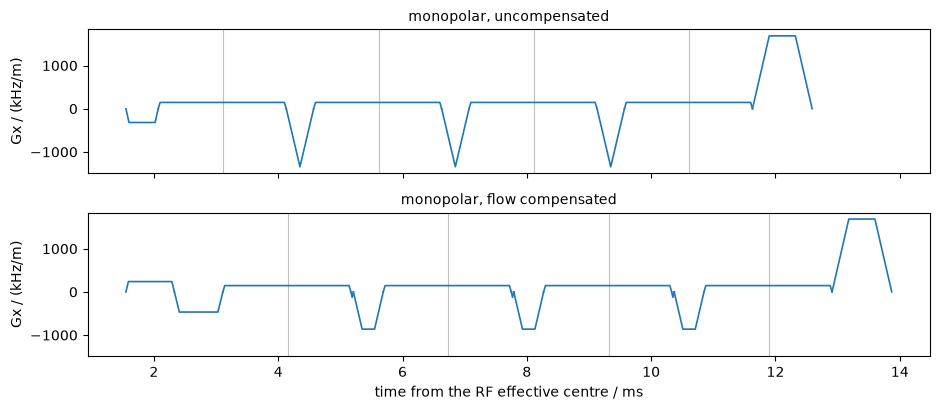

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(9.5, 4.2), sharex=True, sharey=True)
for ax, (tag, extra) in zip(axes, (('uncompensated', {}), ('flow compensated', {'flow_comp': FULL}))):
    kernel = megre('monopolar', **extra)
    shot, t0 = kernel(line=LINE), kernel.exc.time_to_center()
    for start, event, _ in sc.flatten(shot):
        if getattr(event, 'channel', None) != 'x':
            continue
        times, amps = sc.events.knots_of(event, start)
        ax.plot((times - t0) * 1e3, np.asarray(amps) / 1e3, color='tab:blue', lw=1.2)
    for n, te in enumerate(echo_times(kernel)):
        ax.axvline((te - t0) * 1e3, color='0.75', lw=0.8, zorder=0)
    ax.set_title(f'monopolar, {tag}', fontsize=10)
    ax.set_ylabel('Gx / (kHz/m)')
axes[-1].set_xlabel('time from the RF effective centre / ms')
fig.tight_layout()
plt.show()

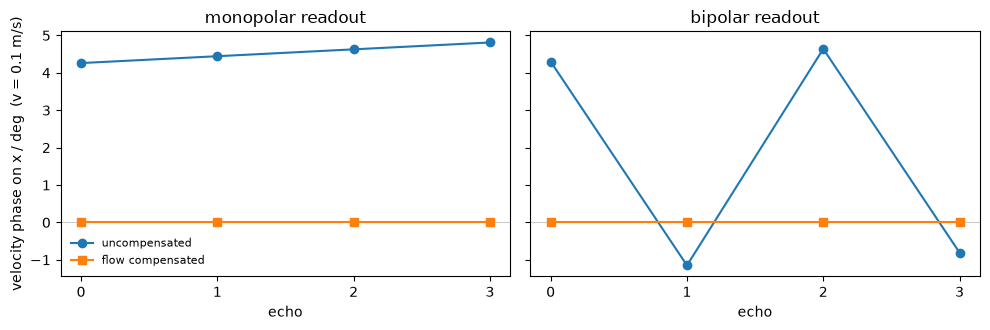

worst echo, velocity phase on x at v = 0.1 m/s

  polarity   uncompensated   flow compensated
 monopolar          4.81 deg        5.2e-14 deg
   bipolar          4.64 deg       9.59e-14 deg


In [11]:
V_M_S = 0.10          # m/s -- an illustrative velocity, to put the first moment in degrees

fig, axes = plt.subplots(1, 2, figsize=(10.0, 3.4), sharey=True)
for ax, polarity in zip(axes, ('monopolar', 'bipolar')):
    echoes = np.arange(ECHOES)
    ax.axhline(0.0, color='0.8', lw=0.8)
    ax.plot(echoes, 360 * uncompensated[polarity][0] * V_M_S, 'o-', label='uncompensated')
    ax.plot(echoes, 360 * compensated[polarity][0] * V_M_S, 's-', label='flow compensated')
    ax.set_title(f'{polarity} readout')
    ax.set_xlabel('echo')
    ax.set_xticks(echoes)
axes[0].set_ylabel(f'velocity phase on x / deg  (v = {V_M_S} m/s)')
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

print(f'worst echo, velocity phase on x at v = {V_M_S} m/s\n')
print(f'{"polarity":>10}{"uncompensated":>16}{"flow compensated":>19}')
for polarity in ('monopolar', 'bipolar'):
    worst = 360 * np.abs(uncompensated[polarity][0]).max() * V_M_S
    done = 360 * np.abs(compensated[polarity][0]).max() * V_M_S
    print(f'{polarity:>10}{worst:14.2f} deg{done:15.3g} deg')

---

## 8. Dummy repetitions

A spoiled gradient echo does not image the equilibrium magnetisation. It images whatever the
magnetisation settles to once the same flip angle, the same TR and the same spoiling have been
applied over and over — the **steady state** — and the first few repetitions after the scanner
starts are not in it. Acquiring them writes a bright, decaying band across the phase-encode
direction of the image, because the first lines of k-space carry far more signal than the rest.

The fix is to play repetitions that drive the magnetisation without recording anything: **dummy
repetitions**, prepended to the scan. `acquire=False` drops the ADC and the acquisition labels and
changes nothing else, so a dummy plays the same RF, the same encoding, the same compensated
transitions and the same TR as the repetition it is preparing for.

That last part matters here. A dummy that used a shorter or uncompensated train would be driving
the magnetisation towards a *different* steady state from the one about to be acquired, and the
band it was supposed to remove would come back smaller and harder to recognise.

In [12]:
def drive_digest(tree):
    # The events that DRIVE the spins -- gradients and RF -- as (start, content hash).
    # ADC and labels are left out, because they are exactly what a dummy is allowed to differ in.
    return sorted((round(start, 12), sc.events.content_hash(event))
                  for start, event, _ in sc.flatten(tree)
                  if getattr(event, 'type', None) in ('trap', 'grad', 'rf'))


for polarity in ('monopolar', 'bipolar'):
    kernel = megre(polarity, flow_comp=FULL)
    dummy = kernel(line=0, phase_deg=0.0, acquire=False)
    acquired = kernel(line=0, phase_deg=0.0, acquire=True)
    kinds = {getattr(event, 'type', None) for _, event, _ in sc.flatten(acquired)}
    dummy_kinds = {getattr(event, 'type', None) for _, event, _ in sc.flatten(dummy)}
    pad = ' ' * len(polarity)
    print(f'{polarity}: gradients and RF identical  '
          f'{drive_digest(dummy) == drive_digest(acquired)}')
    print(f'{pad}  same duration               '
          f'{abs(dummy.duration - acquired.duration) < 1e-12}')
    print(f'{pad}  dropped by acquire=False    '
          f'{sorted(str(k) for k in kinds - dummy_kinds)}')

monopolar: gradients and RF identical  True
           same duration               True
           dropped by acquire=False    ['adc', 'labelset']


bipolar: gradients and RF identical  True
         same duration               True
         dropped by acquire=False    ['adc', 'labelset']


The gradients and the RF are identical event for event — including the compensated winder and
every inter-echo transition — the repetition is exactly as long, and the ADC and the labels are
what `acquire=False` removes. So the dummies drive the magnetisation towards the same steady state
the acquired repetitions will then sample, which is the only reason they are worth playing.

`DUMMIES = 8` here is a round number chosen to demonstrate the pattern. **How many are actually
needed depends on the flip angle, TR, $T_1$ and the spoiling**, and nothing in this notebook
computes that — a protocol that cares should measure the approach to the steady state rather than
inherit a constant from an example.

---

## 9. The files

Each file is the full 64-line acquisition with its dummies in front, so the block count is
`(DUMMIES + MATRIX)` repetitions rather than `MATRIX`.

In [13]:
def write(name, polarity, **extra):
    kernel = megre(polarity, **extra)
    scan = sc.LogicBlock(name)
    # This example holds the first acquired line through the dummy run-in; no stronger
    # equivalence between phase-encode states is claimed.  The RF-spoiling counter runs straight
    # through them, because the steady state they establish is the steady state of that
    # particular phase schedule.
    for index in range(DUMMIES + MATRIX):
        acquired = index >= DUMMIES
        scan.add(index * kernel.tr_s,
                 kernel(line=index - DUMMIES if acquired else 0,
                        phase_deg=0.5 * RF_SPOIL_DEG * index * (index + 1),
                        acquire=acquired))
    sequence = sc.compile(scan, opts)
    sequence.write(str(SEQ_DIR / f'{name}.seq'))
    return sequence


print(f'{"":>26}{"blocks":>9}{"duration / s":>14}   file')
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter('always', sc.SeqCraftWarning)
    for polarity in ('monopolar', 'bipolar'):
        name = f'megre_flowcomp_{polarity}'
        sequence = write(name, polarity, flow_comp=FULL)
        print(f'{polarity + ", flow_comp":>26}{len(sequence.block_events):9d}'
              f'{sequence.duration()[0]:14.3f}   {name}.seq')

# These are the expected same-axis merge and vector-norm diagnostics; there are no per-axis
# hard-limit failures in the emitted sequence.  The distinction matters: a per-axis gradient or
# slew excess would be a hard violation, while exceeding the limit in vector norm is legal on a
# real amplifier unless the rotation semantics make it otherwise.  The merges are one per
# repetition on each axis, where a repetition's last gradient and the next one's first are
# adjacent; the vector-norm sites involve whichever gradients overlap, the compensated ones
# included.
for warning in caught:
    print(f'\n{str(warning.message)[:180]}...')

                             blocks  duration / s   file


      monopolar, flow_comp      936         1.156   megre_flowcomp_monopolar.seq


        bipolar, flow_comp      936         1.313   megre_flowcomp_bipolar.seq

215 same-axis gradient merges: megre_flowcomp_monopolar.GRE2DTR.joint.joint (axis z) x72, megre_flowcomp_monopolar.GRE2DTR.CartesianLine (axis x) x72, megre_flowcomp_monopolar.GRE2...

288 blocks over the vector-norm limit (legal on real amplifiers): megre_flowcomp_monopolar.GRE2DTR.CartesianLine, megre_flowcomp_monopolar.GRE2DTR.joint, megre_flowcomp_monopolar.G...

215 same-axis gradient merges: megre_flowcomp_bipolar.GRE2DTR.joint.joint (axis z) x72, megre_flowcomp_bipolar.GRE2DTR.CartesianLine (axis x) x72, megre_flowcomp_bipolar.GRE2DTR.jo...

288 blocks over the vector-norm limit (legal on real amplifiers): megre_flowcomp_bipolar.GRE2DTR.CartesianLine, megre_flowcomp_bipolar.GRE2DTR.joint, megre_flowcomp_bipolar.GRE2DTR...


---

## Summary

A multi-echo gradient echo controls the zeroth gradient moment at every echo — $k_x$ returns to
zero on each traverse, $k_y$ and $k_z$ hold what the encoding set — and says nothing about the
first. Uncompensated, the first moment on the readout axis climbs monotonically under a monopolar
readout and alternates under a bipolar one, while on the phase-encode and slice axes it is a
single large constant.

`flow_comp=` nulls $M_1$ **at every acquired echo**, on every axis asked for, and the measurement
above finds it at the arithmetic floor on all three axes at all four echoes of both polarities,
with the encoding untouched.

Two different things buy that. On `y` and `z` it is free: those axes are silent from before the
first echo until after the last, and a first moment about a fixed origin stops accruing where the
gradient is zero, so a condition met at the first echo is still met at the last. On `x` the readout
is playing throughout, and the moments propagate as $M_0^{(i+1)} = M_0^{(i)}$ and $M_1^{(i+1)} =
M_1^{(i)} + \mu_i$ — the lever-arm term dropping out because each echo is a $k_x = 0$ crossing. So
every inter-echo interval must satisfy $\Delta M_0 = 0$ **and** $\Delta M_1 = 0$, which is a
condition on the interval as a whole: what plays between the lobes has to cancel the combined
contribution of one lobe's post-echo tail and the next one's pre-echo head.

The two polarities meet it differently. A monopolar train already has a fly-back carrying a whole
lobe's area, and reshaping it into two lobes to carry the first moment too costs 3 % of the echo
spacing. A bipolar train's interval carries no net area, so what it needs is a balanced pair
carrying pure first moment — but its lobes abut, so that waveform is new, and it costs 59 %. Under
this protocol and hardware that **reverses the echo-spacing ordering**: bipolar is the shorter
readout until every echo has to be compensated, after which monopolar is. How large the gap is in
another protocol is a measurement, not a consequence of this one.

The minimum spacing is derived from the waveform rather than from a formula, so it depends on the
gradient system — and on which limit binds. With `max_grad` held fixed, lowering `max_slew`
lengthens the minimum for both polarities. With `max_slew` held fixed, lowering `max_grad` over
80/40/32 mT/m lengthens the **bipolar** minimum and leaves the monopolar one unchanged at 2580 µs,
because there slew and not amplitude is what binds. `echo_spacing_s=None` asks for the shortest
that carries the guarantee; a hard request that cannot is refused with the minimum named.

**What this notebook does not cover.** Image-level artefact reduction is not demonstrated — what is
measured is the velocity-dependent phase term on the emitted waveform. How much artefact that
removes depends on the flow, the protocol and the rest of the sequence, and establishing it needs a
flow phantom or a scanner. The model is first order, constant velocity only; acceleration carries a
second moment, which needs a further lobe and is not implemented. The shortest echo spacing
reported here is the shortest within the waveform family this readout implements and the supplied
`Opts` — not a claim that no shorter waveform exists. And the timing is derived from the amplifier's
hard limits only: peripheral nerve stimulation is checked after the fact with `sc.pns`, not folded
into the design.

## References

Bernstein, King and Zhou, *Handbook of MRI Pulse Sequences*, Elsevier 2004 — §9.2 on gradient
moment nulling, and §16.1 on multi-echo readout trains.

Wu, Liu, Buch, Ye, Cheng and Haacke, *A fully flow-compensated multiecho susceptibility-weighted
imaging sequence: The effects of acceleration and background field on flow compensation*, Magn
Reson Med 76(2):478-489, 2016 — compensating every echo of a multi-echo train, and what it costs.

Pattany et al., *Motion artifact suppression technique (MAST) for MR imaging*, J Comput Assist
Tomogr 11(3):369-377, 1987 — the original description of first-moment nulling.